# Model selection 🧬

In this notebook we uses data transformation such as ordinalEncoder and OneHotEncoder which is necessary to ensure that data is accurate, consistent, and in a usable format for analysis and decision-making.

## Importing Libraries 🛠
We will start by importing the necessary libraries that we will be using throughout the notebook.

- `pandas` - for data manipulation and analysis
- `numpy` - for numerical operations
- `time` - for time-related operations
- `matplotlib` - for data visualization
- `seaborn` - for advanced data visualization
- `train_test_split` - for splitting the dataset into training and testing sets
- `KFold` - for cross-validation
- `GradientBoostingRegressor` - for Gradient Boosting
- `RandomForestRegressor` - for Random Forest
- `ExtraTreesRegressor` - for Extra Trees
- `AdaBoostRegressor` - for AdaBoost
- `DecisionTreeRegressor` - for Decision Tree
- `LassoLars` - for Lasso Regression
- `Ridge` - for Ridge Regression
- `BayesianRidge` - for Bayesian Ridge Regression
- `Lasso` - for Lasso Regression
- `LinearRegression` - for Linear Regression
- `HuberRegressor` - for Huber Regression
- `PassiveAggressiveRegressor` - for Passive Aggressive Regression
- `ElasticNet` - for Elastic Net Regression
- `KNeighborsRegressor` - for K-Nearest Neighbors Regression
- `DummyRegressor` - for Dummy Regression
- `LGBMRegressor` - for LightGBM Regression
- `XGBRegressor` - for XGBoost Regression
- `CatBoostRegressor` - for CatBoost Regression
- `mean_absolute_error` - for Mean Absolute Error
- `mean_squared_error` - for Mean Squared Error
- `r2_score` - for R-Squared Score

In [22]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LassoLars, Ridge, BayesianRidge, Lasso, LinearRegression, HuberRegressor, PassiveAggressiveRegressor, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Loading Data 📁

Next, we will load the dataset using pandas read_parquet function.

In [2]:
df = pd.read_csv("./../data/transform_diamonds.csv")
df

,Shape_CUSHION,Shape_EMERALD,Shape_HEART,Shape_MARQUISE,Shape_OVAL,Shape_PEAR,Shape_PRINCESS,Shape_ROUND,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Weight,Length,Width,Depth,Price
0,1,0,0,0,0,0,0,0,3,17,3,3,2,0,0.549805,5.050781,4.351562,2.939453,1378.65
1,1,0,0,0,0,0,0,0,8,19,3,3,2,2,0.500000,4.601562,4.308594,2.919922,1379.74
2,1,0,0,0,0,0,0,0,5,14,3,3,2,0,0.509766,4.710938,4.351562,2.939453,1380.19
3,1,0,0,0,0,0,0,0,5,14,3,3,2,0,0.500000,4.910156,4.261719,2.880859,1380.61
4,1,0,0,0,0,0,0,0,4,18,3,2,2,0,0.529785,4.699219,4.460938,3.009766,1383.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5890,0,0,0,0,0,0,0,1,4,17,3,3,3,0,0.500000,5.000000,5.039062,3.179688,2453.10
5891,0,0,0,0,0,0,0,1,4,17,3,3,3,0,0.500000,5.031250,5.058594,3.160156,2453.10
5892,0,0,0,0,0,0,0,1,5,18,2,3,2,0,0.500000,4.929688,4.960938,3.189453,2453.20
5893,0,0,0,0,0,0,0,1,4,14,3,3,3,0,0.520020,5.109375,5.128906,3.199219,2453.41


## Data Exploration 🔎

Let's explore the data by checking the columns and their data types.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5895 entries, 0 to 5894
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Shape_CUSHION   5895 non-null   int64  
 1   Shape_EMERALD   5895 non-null   int64  
 2   Shape_HEART     5895 non-null   int64  
 3   Shape_MARQUISE  5895 non-null   int64  
 4   Shape_OVAL      5895 non-null   int64  
 5   Shape_PEAR      5895 non-null   int64  
 6   Shape_PRINCESS  5895 non-null   int64  
 7   Shape_ROUND     5895 non-null   int64  
 8   Clarity         5895 non-null   int64  
 9   Colour          5895 non-null   int64  
 10  Cut             5895 non-null   int64  
 11  Polish          5895 non-null   int64  
 12  Symmetry        5895 non-null   int64  
 13  Fluorescence    5895 non-null   int64  
 14  Weight          5895 non-null   float64
 15  Length          5895 non-null   float64
 16  Width           5895 non-null   float64
 17  Depth           5895 non-null   f

## Define list of models 🤖

In this project we are using this regression models

- Gradient Boosting Regressor
- Random Forest Regressor
- CatBoost Regressor
- Light Gradient Boosting Machine
- Extra Trees Regressor
- AdaBoost Regressor
- Extreme Gradient Boosting
- Lasso Least Angle Regression
- Ridge Regression
- Bayesian Ridge
- Least Angle Regression
- Lasso Regression
- Linear Regression
- Huber Regressor
- Decision Tree Regressor
- Orthogonal Matching Pursuit
- Passive Aggressive Regressor
- Elastic Net
- K Neighbors Regressor
- Dummy Regressor

In [5]:
models = {'Gradient Boosting Regressor': GradientBoostingRegressor(),
          'Random Forest Regressor': RandomForestRegressor(),
          'CatBoost Regressor': CatBoostRegressor(verbose=0,allow_writing_files=False),
          'Light Gradient Boosting Machine': LGBMRegressor(),
          'Extra Trees Regressor': ExtraTreesRegressor(),
          'AdaBoost Regressor': AdaBoostRegressor(),
          'Extreme Gradient Boosting': XGBRegressor(),
          'Lasso Least Angle Regression': LassoLars(),
          'Ridge Regression': Ridge(),
          'Bayesian Ridge': BayesianRidge(),
          'Least Angle Regression': LassoLars(),
          'Lasso Regression': Lasso(),
          'Linear Regression': LinearRegression(),
          'Huber Regressor': HuberRegressor(max_iter=1000),
          'Decision Tree Regressor': DecisionTreeRegressor(),
          'Orthogonal Matching Pursuit': PassiveAggressiveRegressor(),
          'Passive Aggressive Regressor': PassiveAggressiveRegressor(),
          'Elastic Net': ElasticNet(),
          'K Neighbors Regressor': KNeighborsRegressor(),
          'Dummy Regressor': DummyRegressor()}

## Define the k-fold cross-validator 🤏

We will be using the `KFold` function from the `sklearn.model_selection` library to split the data into `k` consecutive folds.

In [7]:
k_fold = KFold(n_splits=3, shuffle=True, random_state=42)

## Split the dataset into training and testing sets 📊

We will be using the `train_test_split` function from the `sklearn.model_selection` library to split the dataset into a training set and a testing set.

In [4]:
X = df.drop('Price', axis=1)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Cross-Validation and Model Evaluation Metrics 🔍📊 

This code block contains a loop that performs k-fold cross-validation to evaluate the performance of multiple regression models. The loop iterates over a dictionary of models, each of which is trained on k-1 folds of the training set and evaluated on the remaining fold. The loop records the mean absolute error (MAE) 👌, mean squared error (MSE) 🔍, root mean squared error (RMSE) 🔢, R-squared (R2) 📈, and the time taken (TT) 🕰️ to fit and evaluate each model. The loop then evaluates each model on the test set and records the evaluation metrics. Finally, the evaluation metrics for each model on the test set are appended to lists for later analysis.

In [8]:
mae = []
mse = []
rmse= []
r2 = []
tt = []

test_mae = []
test_mse = []
test_rmse= []
test_r2 = []
test_tt = []

for model_name, model in models.items():
    mae_scores = []
    mse_scores = []
    rmse_scores = []
    r2_scores = []
    tt_scores = []
    print(f"Model name: {model_name}\n")
    print("Train model")

    for k, (train_index, val_index) in enumerate(k_fold.split(X_train, y_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        start_time = time.time()
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)
        end_time = time.time()

        mae_scores.append(round(mean_absolute_error(y_val_fold, y_pred), 4))
        mse_scores.append(round(mean_squared_error(y_val_fold, y_pred), 4))
        rmse_scores.append(round(mean_squared_error(y_val_fold, y_pred, squared=False), 4))
        r2_scores.append(round(r2_score(y_val_fold, y_pred), 4))
        tt_scores.append(round(end_time - start_time, 4))
        
        print(f"Fold: {k}\tMAE: {mae_scores[-1]:.4f}\tMSE: {mse_scores[-1]:.4f}\tRMSE: {rmse_scores[-1]:.4f}\tR2: {r2_scores[-1]:.4f}\tTT: {tt_scores[-1]:.4f}")

    
    mae.append(np.mean(mae_scores))
    mse.append(np.mean(mse_scores))
    rmse.append(np.mean(rmse_scores))
    r2.append(np.mean(r2_scores))
    tt.append(np.mean(tt_scores))
    
    print("\nTest model")
    start_time = time.time()
    y_pred = model.predict(X_test)
    end_time = time.time()

    mae_scores.append(round(mean_absolute_error(y_test, y_pred), 4))
    mse_scores.append(round(mean_squared_error(y_test, y_pred), 4))
    rmse_scores.append(round(mean_squared_error(y_test, y_pred, squared=False), 4))
    r2_scores.append(round(r2_score(y_test, y_pred), 4))
    tt_scores.append(round(end_time - start_time, 4))
    
    print(f"Fold: -\tMAE: {mae_scores[-1]:.4f}\tMSE: {mse_scores[-1]:.4f}\tRMSE: {rmse_scores[-1]:.4f}\tR2: {r2_scores[-1]:.4f}\tTT: {tt_scores[-1]:.4f}")
    
    test_mae.append(mae_scores[-1])
    test_mse.append(mse_scores[-1])
    test_rmse.append(rmse_scores[-1])
    test_r2.append(r2_scores[-1])
    test_tt.append(tt_scores[-1])
    
    print("\n"+"="*100+"\n")
    

Model name: Gradient Boosting Regressor

Train model
Fold: 0	MAE: 224.7372	MSE: 261971.1195	RMSE: 511.8311	R2: 0.8873	TT: 0.4476
Fold: 1	MAE: 253.1958	MSE: 454447.9312	RMSE: 674.1275	R2: 0.8531	TT: 0.2913
Fold: 2	MAE: 230.6118	MSE: 351107.1568	RMSE: 592.5430	R2: 0.8685	TT: 0.2761

Test model
Fold: -	MAE: 246.8139	MSE: 426968.2167	RMSE: 653.4281	R2: 0.8469	TT: 0.0023


Model name: Random Forest Regressor

Train model
Fold: 0	MAE: 201.5742	MSE: 295963.5875	RMSE: 544.0254	R2: 0.8726	TT: 1.0430
Fold: 1	MAE: 225.8366	MSE: 486818.0258	RMSE: 697.7235	R2: 0.8426	TT: 1.0460
Fold: 2	MAE: 217.5591	MSE: 388202.5748	RMSE: 623.0590	R2: 0.8546	TT: 1.1533

Test model
Fold: -	MAE: 226.8002	MSE: 389923.9129	RMSE: 624.4389	R2: 0.8602	TT: 0.0294


Model name: CatBoost Regressor

Train model
Fold: 0	MAE: 177.3680	MSE: 207877.0197	RMSE: 455.9353	R2: 0.9105	TT: 2.1812
Fold: 1	MAE: 197.9240	MSE: 340714.3270	RMSE: 583.7074	R2: 0.8898	TT: 1.1907
Fold: 2	MAE: 195.7100	MSE: 310586.9766	RMSE: 557.3033	R2: 0.8837	T

Results table showing the performance metrics of different regression models in train dataset

In [9]:
results = pd.DataFrame({
    'Model': list(models.keys()),
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2,
    'TT (Sec)': tt
})

results.sort_values("R2", axis=0, ascending=False).reset_index(drop=True)

,Model,MAE,MSE,RMSE,R2,TT (Sec)
0,CatBoost Regressor,190.334000,2.863928e+05,532.315333,0.894667,1.519233
1,Gradient Boosting Regressor,236.181600,3.558421e+05,592.833867,0.869633,0.338333
2,Extra Trees Regressor,205.015167,3.669427e+05,603.329567,0.864767,0.785033
3,Random Forest Regressor,214.989967,3.903281e+05,621.602633,0.856600,1.080767
4,Light Gradient Boosting Machine,213.279300,3.922670e+05,625.596500,0.854133,0.746200
5,Extreme Gradient Boosting,211.245867,4.107498e+05,637.078433,0.849367,0.780567
6,K Neighbors Regressor,347.010167,6.644505e+05,812.615700,0.753200,0.126967
7,Linear Regression,418.807700,7.449175e+05,862.479100,0.721900,0.032533
8,Bayesian Ridge,417.863867,7.451681e+05,862.610867,0.721867,0.017667
9,Ridge Regression,416.316667,7.460611e+05,863.093300,0.721600,0.024133


Results table showing the performance metrics of different regression models in test dataset

In [10]:
test_results = pd.DataFrame({
    'Model': list(models.keys()),
    'MAE': test_mae,
    'MSE': test_mse,
    'RMSE': test_rmse,
    'R2': test_r2,
    'TT (Sec)': test_tt
})

test_results.sort_values("R2", axis=0, ascending=False).reset_index(drop=True)

,Model,MAE,MSE,RMSE,R2,TT (Sec)
0,CatBoost Regressor,206.8450,3.519263e+05,593.2338,0.8738,0.0038
1,Random Forest Regressor,226.8002,3.899239e+05,624.4389,0.8602,0.0294
2,Extreme Gradient Boosting,219.3328,4.028887e+05,634.7352,0.8556,0.0060
3,Gradient Boosting Regressor,246.8139,4.269682e+05,653.4281,0.8469,0.0023
4,Extra Trees Regressor,223.1459,4.290092e+05,654.9879,0.8462,0.0311
5,Light Gradient Boosting Machine,231.0250,4.462563e+05,668.0242,0.8400,0.0039
6,Decision Tree Regressor,274.8801,5.511628e+05,742.4034,0.8024,0.0020
7,K Neighbors Regressor,360.9694,7.398412e+05,860.1402,0.7348,0.0159
8,Ridge Regression,447.5752,8.176918e+05,904.2631,0.7069,0.0019
9,Bayesian Ridge,448.9835,8.183888e+05,904.6484,0.7066,0.0018


**Insight 💡**

- The CatBoost Regressor has the highest R2 value, indicating that it explains the variance in the target variable the best among all the models.
- The CatBoost Regressor has the lowest MAE, MSE, and RMSE among all the models, which indicates that it is the best-performing model in terms of accuracy.
- The Random Forest Regressor, Extreme Gradient Boosting, and Extra Trees Regressor models also perform well and have R2 values above 0.84.
- The Linear Regression, Ridge Regression, and Bayesian Ridge models have similar performance, with R2 values around 0.70 and relatively high MAE, MSE, and RMSE values.
- The Dummy Regressor has a negative R2 value, indicating that it is worse than the mean predictor in terms of accuracy.
- The training time (TT) is generally low for most of the models, with the highest value being 0.0311 seconds for the Extra Trees Regressor.

Overall, the CatBoost Regressor is the best model for this dataset, as it has the lowest error metrics and the highest R2 value.

### Training CatBoostRegressor model 

Training the model to get more insights

In [11]:
regressor = CatBoostRegressor(verbose=0, allow_writing_files=False)

In [12]:
regressor.fit(X_train, y_train)

## Feature importance

Using `regressor.feature_importances_` we will get which feature is important or not

In [30]:
transform_df = pd.DataFrame([regressor.feature_importances_], columns=['Shape_CUSHION', 'Shape_EMERALD', 'Shape_HEART', 'Shape_MARQUISE', 'Shape_OVAL', 'Shape_PEAR', 'Shape_PRINCESS', 'Shape_ROUND', 'Clarity', 'Colour', 'Cut', 'Polish', 'Symmetry', 'Fluorescence','Weight', 'Length','Width', 'Depth'], index=['feature_importances'])
transform_df = transform_df.T
transform_df.sort_values(by=["feature_importances"],ascending=False, inplace = True)
transform_df

,feature_importances
Weight,32.934920
Colour,18.784300
Depth,12.676299
Width,10.458805
Length,9.102871
Clarity,7.906486
Shape_PEAR,2.912063
Symmetry,1.700261
Polish,1.345479
Shape_CUSHION,0.719666


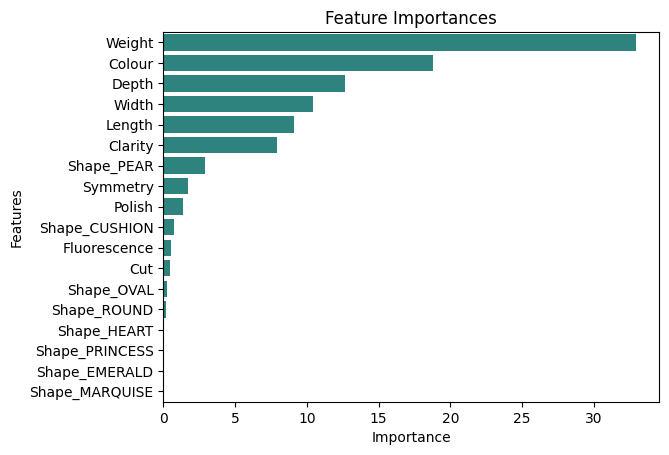

In [32]:
sns.barplot(x='feature_importances', y=transform_df.index, data=transform_df, color='#21918c')

# set the title and axis labels
plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Features')

# show the plot
plt.show()

**Insight 💡**

- The "Weight" feature has the highest importance at 32.93%, followed by "Colour" at 18.78% and "Depth" at 12.67%.
- "Width" and "Length" have importance levels of 10.45% and 9.10%, respectively.
- "Clarity" and "Shape_PEAR" have importance levels of 7.91% and 2.91%, respectively.
- "Symmetry", "Polish", "Shape_CUSHION", and "Fluorescence" have relatively lower importance levels, ranging from 1.70% to 0.53%.
- The remaining features, including "Cut", "Shape_OVAL", "Shape_ROUND", "Shape_HEART", "Shape_PRINCESS", "Shape_EMERALD", and "Shape_MARQUISE" have very low importance levels, all below 1%.

## Conclusion 🎉

In this notebook, we performed several regression models for our project and selecting the best one. We started by importing necessary libraries, loading the dataset, and applied several regression models and selecting best model using k-folds. 

By observation, we can conclude that CatBoost Regressor is the best model for this dataset, as it has the lowest error metrics and the highest R2 value.

Finally, we also got insights about feature importance. Overall, these steps helped us to create base model which makes it ready for further pipeline.